# Project 3: Multi-Agent Reinforcement Learning

### Group number
### Anton Mlynczyk - 1007283226
### Osman Sultan - 1006803014
### Sunghoo (Kevin) Kim - 1006820013
### Gaeun (Grace) Yim - 1011904824

Please read all instructions carefully before attempting each part of the problem. Each team only needs to have one submission with all the names of team-members and group number at the beginning of the jupyter notebook.

The jupyter notebook should contain your code, discussions, derivations, analysis and relevant figures. Make sure the code, plots and videos shown in your file can be reproduce when I rerun the code in grading. Feel free to add or move Cells.

In this project, you will implement three different multi-agent reinforcement learning algorithms to solve a navi-
gation problem involving two agents and then compare the results.

### 1. The Invader-Defender Game [10 Marks]

The task you will be implementing for this assignment is defined as follow:

- Time is broken up into discrete epochs.
- The world is a square area that is broken up into a 6-by-6 grid of cells.
- There are two players or agents; both of them can move up, down, left, or right. At each time step, both players take their action simultaneously. Each cannot see the others' action at that time step, but the state of the system and previous actions are fully observable to each. If the chosen action takes an agent outside of the grid, then the agent remains in the current position.
- The invader, marked I, starts in the upper-left corner of the world. The defender, marked D, starts in the bottom-left corner of the world.
- The 9 cells centered around the defender's current position (see Figure 1), is the region where the invader has a 90% chance of beign captured. The game ends whenever the invader is captured by the defender, or the invader enters the fixed territory cell marked T, whichever comes first. The discount factor for future rewards is $\gamma = 0.95$.
- The goal of the defender is to capture the invader as far away as possible from the territory T. The goal of the invader is to move as close as possible to the territory T before being captured.


1.1 Explain how you would model this problem as a stochastic game: [10 Marks]

   (a) What is the state space, and what are the action spaces for each agent?

   State Space: Position on the grid of both agents. State: ((p1_loc), (p2_loc)) (e.g) -> ((0, 0), (1, 1))

   Action Space (for each agent): Left, Right, Up, Down

   (b) Describe the transition probability matrix for this stochastic game.

   The matrix is a 6^4 x 6^4 grid that denotes the probability of transitioning from one state to another. It has this dimension because each has 36 (6^2) possible positions that it can exist in, and each state models the position of both agents. However, most of entries within the matrix are zero since each agent can only move to its adjacent states within the board with equal probability. 

   (c) Which states, if any, are terminal states?

   One clear terminal state is when the Invader reaches the Goal (T).

   There are several other terminal states based on the location of the Defender and whether the game terminates with 90% probabiliy. For each location that the Defender is in on the 6x6 grid, if the Invader is within the surrounding 3x3 grid, there is a 90% probability that the game terminates (the Defender captures the Invader) in given state (which includes the position of both the defender and invader).
    
   (d) Derive one suitable reward function that allows the defender to achieve the goal for this task. Derive one suitable reward function that allows the invader to achieve the goal for this task. Are these the only possible suitable reward functions? Why or why not? What is the relationship between the defender's and invader's reward functions? Choosing a good reward function is critical to get good results in RL, so please choose carefully.

   Non-terminal
   Invader: (Negative Manhattan Distance between Invader & Goal) + (Positive Manhattan Distance between Invader & Defender) 
   Defender: (Positive Manhattan Distance between Invader & Goal) + (Negative Manhattan Distance between Invader & Defender) 

   Terminal:
   If Captured:
   Invader: Negative Manhattan Distance between Invader & Goal; Defender: Positive Manhattan Distance between Invader & Goal

   If Invader reach goal:
   Invader: +20; Defender: -20
    
   (e) What kind of stochastic game is this (e.g. what special properties does it possess based on what you have learned about stochastic games)?

   Two-player Zero-sum Stoachstic Game with Simultaneous Actions

   The reward must add up to 0 for each joint action.

1.2 Now, you are asked to implement the behavior of the invader/defender domain in a Python code. Create a
python class called InvaderDefenderEnv. Here, you should create functions similar to what you have done
in Projects 1 and 2, but for the stochastic game. In particular, you would want to consider functions to:
return a list of possible states in the game; given a state, check if it is terminal; given a transition, return its
probability of occurring and the immediate reward (these should be consistent with your answers to part 1 of
the question); and given a state and actions of the agents, return the next state of the game (to simulate the
task behavior for Q-learning) [10 Marks]


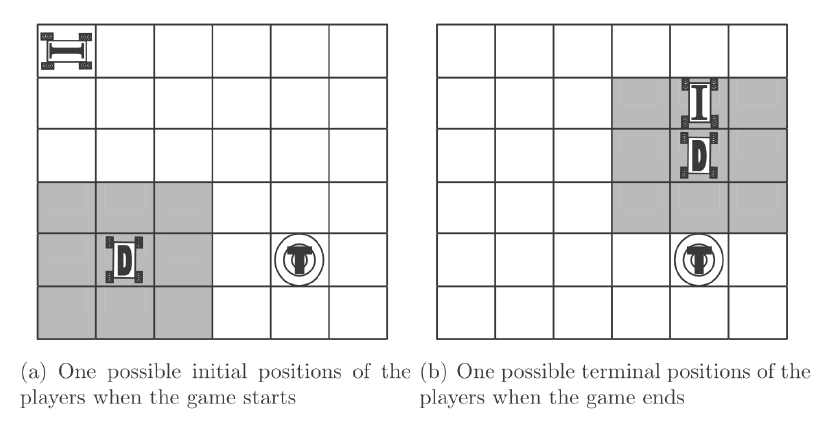

#### 1.2.0 Package Installation

In [ ]:
!pip install numpy

In [2]:
import numpy as np
import random
from matplotlib import pyplot as plt
import seaborn as sns

#### 1.2.1 Environment Implementation

In [3]:
class InvaderDefenderEnv:
    def __init__(self):
        self.grid_size = 6
        self.territory_pos = (4, 4)  # Fixed territory position
        self.invader_pos = (0, 0)     # Initial invader position
        self.defender_pos = (5, 0)    # Initial defender position
        self.actions = ['l', 'r', 'u', 'd']
        self.action_effects = {
            'l': (0, -1),
            'r': (0, 1),
            'u': (-1, 0),
            'd': (1, 0),
        }

    def get_all_states(self):
        """Return all possible states as tuples of (invader_pos, defender_pos)."""
        states = []
        for i_x in range(self.grid_size):
            for i_y in range(self.grid_size):
                for d_x in range(self.grid_size):
                    for d_y in range(self.grid_size):
                        states.append(((i_x, i_y), (d_x, d_y)))
        return states
    
    def is_terminal(self, state):
        """Check if the state is terminal (invader reached T)."""
        invader_pos, _ = state
        return invader_pos == self.territory_pos
    
    def move_agent(self, pos, action):
        """Move an agent, clipping to grid boundaries."""
        dx, dy = self.action_effects[action]
        new_x = np.clip(pos[0] + dx, 0, self.grid_size - 1)
        new_y = np.clip(pos[1] + dy, 0, self.grid_size - 1)
        return (new_x, new_y)
    
    def is_in_defender_area(self, invader_pos, defender_pos):
        """Check if invader is within defender's 3x3 area."""
        d_x, d_y = defender_pos
        i_x, i_y = invader_pos
        return (d_x - 1 <= i_x <= d_x + 1) and (d_y - 1 <= i_y <= d_y + 1)
    
    def manhattan_distance(self, pos1, pos2):
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])
    
    def get_transition_info(self, state, invader_action, defender_action):
        """
        Return list of (probability, next_state, invader_reward, defender_reward, terminated).
        """
        invader_pos, defender_pos = state
        transitions = []

        if self.is_terminal(state):
            transitions.append((1.0, state, 0, 0, True))
            return transitions

        # Check if invader is in defender's 3x3 area
        in_defender_area = self.is_in_defender_area(invader_pos, defender_pos)

        if in_defender_area:
            # 90% chance of capture (game ends immediately)
            capture_distance = self.manhattan_distance(invader_pos, self.territory_pos)
            transitions.append((
                0.9,
                state,  # No movement
                -capture_distance,  # Invader reward
                capture_distance,   # Defender reward
                True
            ))

            # 10% chance: both agents move
            new_i_pos = self.move_agent(invader_pos, invader_action)
            new_d_pos = self.move_agent(defender_pos, defender_action)
            new_state = (new_i_pos, new_d_pos)
            if new_i_pos == self.territory_pos:
                # Invader reached T
                transitions.append((0.1, new_state, 20, -20, True))
            else:
                # Non-terminal reward
                distance_to_T = self.manhattan_distance(new_i_pos, self.territory_pos)
                distance_to_defender = self.manhattan_distance(new_i_pos, new_d_pos)
                invader_reward = -distance_to_T + distance_to_defender
                defender_reward = distance_to_T - distance_to_defender
                transitions.append((0.1, new_state, invader_reward, defender_reward, False))
        else:
            # No capture chance
            new_i_pos = self.move_agent(invader_pos, invader_action)
            new_d_pos = self.move_agent(defender_pos, defender_action)
            new_state = (new_i_pos, new_d_pos)
            if new_i_pos == self.territory_pos:
                transitions.append((1.0, new_state, 20, -20, True))
            else:
                distance_to_T = self.manhattan_distance(new_i_pos, self.territory_pos)
                distance_to_defender = self.manhattan_distance(new_i_pos, new_d_pos)
                invader_reward = -distance_to_T + distance_to_defender
                defender_reward = distance_to_T - distance_to_defender
                transitions.append((1.0, new_state, invader_reward, defender_reward, False))

        return transitions
    
    def step(self, state, invader_action, defender_action):
        """Simulate one step with given actions. Returns next_state, rewards, terminal"""

        transitions = self.get_transition_info(
            state,
            invader_action,
            defender_action
        )
        # Sample a transition based on probabilities
        probs = [t[0] for t in transitions]
        chosen_idx = np.random.choice(len(transitions), p=probs)
        _, next_state, invader_r, defender_r, terminal = transitions[chosen_idx]
        self.invader_pos, self.defender_pos = next_state
        return next_state, (invader_r, defender_r), terminal
    
    def reset(self):
        """Reset to initial positions."""
        self.invader_pos = (0, 0)
        self.defender_pos = (5, 0)
        return (self.invader_pos, self.defender_pos)
    


#### 1.2.2 Environemnt Tests

In [4]:
import unittest

class TestInvaderDefenderEnv(unittest.TestCase):
    def setUp(self):
        self.env = InvaderDefenderEnv()
        self.env.reset()

    # --------------------------
    # Test Helper Methods
    # --------------------------
    def test_move_agent(self):
        # Test movement within bounds
        self.assertEqual(self.env.move_agent((3, 3), 'u'), (2, 3))
        self.assertEqual(self.env.move_agent((3, 3), 'l'), (3, 2))

        # Test boundary clamping
        self.assertEqual(self.env.move_agent((0, 0), 'u'), (0, 0))  # Can't move up
        self.assertEqual(self.env.move_agent((5, 5), 'r'), (5, 5))  # Can't move right

    def test_is_in_defender_area(self):
        # Defender at (3,3)
        self.assertTrue(self.env.is_in_defender_area((3,3), (3,3)))  # Same cell
        self.assertTrue(self.env.is_in_defender_area((2,2), (3,3)))  # Top-left corner of 3x3
        self.assertFalse(self.env.is_in_defender_area((1,3), (3,3)))  # Outside 3x3
        self.assertFalse(self.env.is_in_defender_area((0,0), (3,3)))  # Outside 3x3
        self.assertTrue(self.env.is_in_defender_area((4,4), (5,5)))  # right corner

    # --------------------------
    # Test State Management
    # --------------------------
    def test_terminal_state_detection(self):
        # Non-terminal state
        self.assertFalse(self.env.is_terminal(((0,0), (5,0))))

        # Terminal state (invader at T)
        self.assertTrue(self.env.is_terminal(((4,4), (3,3))))

    def test_reset(self):
        self.env.invader_pos = (3,3)
        self.env.defender_pos = (2,2)
        self.env.reset()
        self.assertEqual(self.env.invader_pos, (0,0))
        self.assertEqual(self.env.defender_pos, (5,0))

    # --------------------------
    # Test Transitions & Rewards
    # --------------------------
    def test_capture_transition(self):
        # Force invader into defender's area
        state = ((3,3), (3,3))  # Invader at defender's position
        transitions = self.env.get_transition_info(state, 'u', 'd')

        # Should have 2 transitions: 90% capture, 10% movement
        self.assertEqual(len(transitions), 2)
        
        # Check capture reward
        capture_reward = self.env.manhattan_distance((3,3), self.env.territory_pos)
        self.assertEqual(transitions[0][2], -capture_reward)  # Invader reward
        self.assertEqual(transitions[0][3], capture_reward)   # Defender reward

    def test_goal_reached_transition(self):
        # Invader one step away from T
        state = ((4,3), (5,0))
        transitions = self.env.get_transition_info(state, 'r', 'u')

        # Next state should be terminal with +10/-10 rewards
        self.assertEqual(transitions[0][1], ((4,4), (4,0)))
        self.assertEqual(transitions[0][2], 20)  # Invader
        self.assertEqual(transitions[0][3], -20) # Defender

    def test_edge_case_movement(self):
        # Defender at edge of grid (5,0) tries to move down
        state = ((0,0), (5,0))
        transitions = self.env.get_transition_info(state, 'd', 'd')

        # Defender should stay at (5,0) due to boundary
        new_defender_pos = transitions[0][1][1]
        self.assertEqual(new_defender_pos, (5,0))

    # --------------------------
    # Test Step Function
    # --------------------------
    def test_step_termination(self):
        init_state = (self.env.invader_pos, self.env.defender_pos)
        # Force invader to T in one step
        next, _, _ = self.env.step(init_state, 'r', 'd')  # Irrelevant defender action
        next, _, _ = self.env.step(next, 'r', 'd')  # Repeat until T is reached
        next, _, _ = self.env.step(next, 'r', 'd')  # Irrelevant defender action
        next, _, _ = self.env.step(next, 'r', 'd')  # Repeat until T is reached
        next, _, _ = self.env.step(next, 'd', 'd')  # Irrelevant defender action
        next, _, _ = self.env.step(next, 'd', 'd')  # Repeat until T is reached
        next, _, _ = self.env.step(next, 'd', 'd')  # Irrelevant defender action
        next, _, _ = self.env.step(next, 'd', 'd')  # Repeat until T is reached

        # After reaching T, further steps should do nothing
        _, rewards, done = self.env.step(next, 'u', 'u')
        self.assertTrue(done)
        self.assertEqual(rewards, (0, 0))

    def test_probabilistic_capture(self):
        # Test capture probability distribution
        state = ((3,3), (3,3))
        self.env.invader_pos, self.env.defender_pos = state
        
        # Simulate 1000 steps and count terminations
        captures = 0
        for _ in range(1000):
            self.env.reset()
            self.env.invader_pos, self.env.defender_pos = state
            _, _, done = self.env.step(state, 'u', 'u')
            if done:
                captures += 1
        print(captures / 1000)
        # Check if ~90% captures (allow small tolerance)
        self.assertAlmostEqual(captures / 1000, 0.9, delta=0.05)

In [5]:
test_suite = unittest.TestLoader().loadTestsFromTestCase(TestInvaderDefenderEnv)

# Run tests and print output
unittest.TextTestRunner(verbosity=2).run(test_suite)

test_capture_transition (__main__.TestInvaderDefenderEnv.test_capture_transition) ... ok
test_edge_case_movement (__main__.TestInvaderDefenderEnv.test_edge_case_movement) ... ok
test_goal_reached_transition (__main__.TestInvaderDefenderEnv.test_goal_reached_transition) ... ok
test_is_in_defender_area (__main__.TestInvaderDefenderEnv.test_is_in_defender_area) ... ok
test_move_agent (__main__.TestInvaderDefenderEnv.test_move_agent) ... ok
test_probabilistic_capture (__main__.TestInvaderDefenderEnv.test_probabilistic_capture) ... ok
test_reset (__main__.TestInvaderDefenderEnv.test_reset) ... ok
test_step_termination (__main__.TestInvaderDefenderEnv.test_step_termination) ... ok
test_terminal_state_detection (__main__.TestInvaderDefenderEnv.test_terminal_state_detection) ... ok

----------------------------------------------------------------------
Ran 9 tests in 0.046s

OK


0.901


<unittest.runner.TextTestResult run=9 errors=0 failures=0>

### 2. Multi-agent Reinforcement Learning [60 Marks]

Now that you have defined the environment needed to perform optimization, you are next asked to implement three
of the standard multi-agent reinforcement learning algorithms you have learned in this course.

2.1. Distributed Q-learning. [20 points]

2.2. Shapley Value Iteration. [20 points]

2.3. MiniMax Q-learning. [20 points]

For MiniMax Q-learning, you should train the algorithm for both agents and sample each agent's own policy to
test them. Investigate whether running the trained policy for both agents would lead to the coordination issue in
the MiniMax Q-learning algorithm.

You can implement each algorithm in a seperate Python function or class. Also, your implementation must have
a train function to run your experiment. Here, you will have to initialize your domain, and the algorithm with your
parameter settings, and run your algorithm.

For each of the three algorithms:

(a) set the value function or Q-values initially to zeros.

(b) for solving an LP, you should use the scipy package (in this case, make sure you are correctly inputting the bounds).

(c) for Q-learning, fix the episode length for training and testing to T = 200.

(d) the number of episodes can be adjusted to obtain convergence as you see necessary; for value iteration, you can stop updates when the maximum difference in value functions between two iterations drops below $10^{-6}$. For Q-learning based methods, you have to define the number episodes required for converge. A criteria for setting up the number of episodes can be maximum difference in value functions. Your criteria should be explained in the project.

(e) in this project, we are giving you full control to experiment with hyper-parameters that you think work well overall (e.g. learning rate, $\epsilon$), but please be consistent in your choice across algorithms.

(f) for all algorithms, testing should be done using the greedy policy on separate rollouts (trajectories) at the end of each training episode.

For each algorithm, you should report the following:

I. a table containing hyper-parameter values you used in your experiments.

II. plots of the training and testing performance over time as a function of the number of training episodes already performed (for value iteration, your training performance can be the error in V between iterations. For algorithms with a Q function training performance over time can be the difference between new and old Q functions. Testing performance over time can be total reward per episode).

III. 2D heat-maps showing: (1) the final value function from the invader's perspective as a function of the invader's starting position, when the defender starting position is fixed at x = 0, y = 5, and (2) the final value function from the defender's perspective as a function of the defender's starting position when the invader's starting position is fixed at x = 0, y = 0.

IV. a pictorial representation (you may include a drawing based on the output of your code) of the agents' motion in the grid during a typical testing episode once the algorithm has converged.

#### 2.1 Distributed Q-Learning

In [34]:
class DistributedQLearning():
    def __init__(self, env : InvaderDefenderEnv, lr=5e-5, epsilon=0.1, convergence_threshold=1e-4):
        self.env = env
        self.alpha = lr
        self.gamma = 0.95 # given 
        self.epsilon = epsilon
        self.convergence_threshold = convergence_threshold
        self.Q_inv = {(state, action): 0 for state in self.env.get_all_states() for action in self.env.actions}
        self.Q_def = {(state, action): 0 for state in self.env.get_all_states() for action in self.env.actions}
        self.Q_inv_old = {(state, action): 0 for state in self.env.get_all_states() for action in self.env.actions}
        self.Q_def_old = {(state, action): 0 for state in self.env.get_all_states() for action in self.env.actions}
        self.policy_inv = {state: {action: 0 for action in self.env.actions} for state in self.env.get_all_states()}
        self.policy_def = {state: {action: 0 for action in self.env.actions} for state in self.env.get_all_states()}

    def reset_policy(self):
        self.policy_inv = {state: {action: 0 for action in self.env.actions} for state in self.env.get_all_states()}
        self.policy_def = {state: {action: 0 for action in self.env.actions} for state in self.env.get_all_states()}

    def epsilon_greedy_policy(self, state):
        prob = random.uniform(0, 1)

        if prob <= self.epsilon:
            return random.choice(self.env.actions), random.choice(self.env.actions)
        else:
            inv_q_max, def_q_max = float('-inf'), float('-inf')
            inv_greedy, def_greedy = 'l', 'l'
            for action in self.env.actions:
                inv_q, def_q = self.Q_inv[(state, action)], self.Q_def[(state, action)]
                if inv_q > inv_q_max:
                    inv_greedy = action
                    inv_q_max = inv_q
                if def_q > def_q_max:
                    def_greedy = action
                    def_q_max = def_q
            return inv_greedy, def_greedy


    def plot_curves(self, num_episodes, inv_q_dff_vals, def_q_diff_vals, inv_reward_vals, def_reward_vals):
        # Performance Curves
        if num_episodes <= 1000:
            k = 100
        else:
            k = 1000
            
        plt.figure(figsize=(10, 5))
        plt.title("Training Performance: Maximum Difference in Q-values for both Players")
        plt.plot(range(num_episodes), inv_q_dff_vals, label='Invader')
        plt.plot(range(num_episodes), def_q_diff_vals, label='Defender')
        plt.xticks(range(0, num_episodes, k))
        plt.xlabel("Episode")
        plt.ylabel("Q Difference")
        plt.legend()
        plt.show()

        plt.figure(figsize=(10, 5))
        plt.title("Testing Performance: Total Rewards for both Players")
        plt.plot(range(num_episodes), inv_reward_vals, label='Invader')
        plt.plot(range(num_episodes), def_reward_vals, label='Defender')
        plt.xticks(range(0, num_episodes, k))
        plt.xlabel("Episode")
        plt.ylabel("Total Reward")
        plt.legend()
        plt.show()

        # Heat Maps
        fixed_defender = (0, 5)
        inv_heat_values = []
        for inv_x in range(6):
            temp = []
            for inv_y in range(6):
                inv_starting = (inv_x, inv_y)
                temp.append(max([self.Q_inv[((inv_starting, fixed_defender), action)] for action in self.env.actions]))
            inv_heat_values.append(temp)
        inv_heat_values = np.array(inv_heat_values)

        fixed_invader = (0, 0)
        def_heat_values = []
        for def_x in range(6):
            temp = []
            for def_y in range(6):
                def_starting = (def_x, def_y)
                temp.append(max([self.Q_def[((fixed_invader, def_starting), action)] for action in self.env.actions]))
            def_heat_values.append(temp)
        def_heat_values = np.array(def_heat_values)
        
        plt.title("Final Value Heat Map from Invader Perspective")
        sns.heatmap(inv_heat_values, annot=True)
        plt.show()

        plt.title("Final Value Heat Map from Defender Perspective")
        sns.heatmap(def_heat_values, annot=True)
        plt.show()


    def execute_policy(self, testing=False):
        curr_state = self.env.reset()
        inv_total_reward, def_total_reward = 0, 0
        terminated = False
        trajectory_counter = 0
        while not terminated:
            inv_opt_actions, def_opt_actions = [], []
            for action in self.env.actions:
                if self.policy_inv[curr_state][action] > 0:
                    inv_opt_actions.append(action)
                if self.policy_def[curr_state][action] > 0:
                    def_opt_actions.append(action)
            
            inv_action = random.choice(inv_opt_actions)
            def_action = random.choice(def_opt_actions)
            new_state, (inv_reward, def_reward), terminated = self.env.step(curr_state, inv_action, def_action)
            
            inv_total_reward += inv_reward
            def_total_reward += def_reward

            if testing:
                print(f"Timestamp: {trajectory_counter}")
                print(f"\tCurrent State: {curr_state}")
                print(f"\tInvader Action: {inv_action}; Defender Action: {def_action}")
                print(f"\tNext State: {new_state}")

            trajectory_counter += 1
    
            if terminated:
                print("\tGame terminated")
                if new_state == curr_state:
                    print("\tInvader Captured")
                if new_state[0] == self.env.territory_pos:
                    print("\tTerritory Captured")
                print(f"\tTerminating State: {new_state}")
                print(f"\tNumber of Steps: {trajectory_counter}")
                return inv_total_reward, def_total_reward

            if trajectory_counter >= 200:
                print("\tExceeded 200 steps")
                return inv_total_reward, def_total_reward

            curr_state = new_state


    def train(self):
        counter = 0
        inv_q_diff_vals, def_q_diff_vals = [], []
        inv_reward_vals, def_reward_vals = [], []
        while True:
            state = self.env.reset()
            inv_delta, def_delta = 0, 0
            for k in range(200):
                inv_action, def_action = self.epsilon_greedy_policy(state)
                new_state, (inv_reward, def_reward), terminated = self.env.step(state, inv_action, def_action)
                
                # find the max Q value for invader and defender with the new state
                inv_q_max, def_q_max = float('-inf'), float('-inf')
                for action in self.env.actions:
                    inv_q_max, def_q_max = max(self.Q_inv[(new_state, action)], inv_q_max), max(self.Q_def[(new_state, action)], def_q_max)

                # store old Q
                self.Q_inv_old[(state, inv_action)] = self.Q_inv[(state, inv_action)]
                self.Q_def_old[(state, def_action)] = self.Q_def[(state, def_action)]
            
                # update Q independently
                self.Q_inv[(state, inv_action)] += self.alpha * (inv_reward + self.gamma * inv_q_max - self.Q_inv[(state, inv_action)])
                self.Q_def[(state, def_action)] += self.alpha * (def_reward + self.gamma * def_q_max - self.Q_def[(state, def_action)])

                # find difference in update
                inv_delta = max(inv_delta, abs(self.Q_inv_old[(state, inv_action)] - self.Q_inv[(state, inv_action)]))
                def_delta = max(def_delta, abs(self.Q_def_old[(state, def_action)] - self.Q_def[(state, def_action)]))
            
                if terminated:
                    break

                state = new_state

            # implement testing
            # update policy
            self.reset_policy()
            for state in self.env.get_all_states():
                inv_q_max, def_q_max = float('-inf'), float('-inf')
                for action in self.env.actions:
                    inv_q_max, def_q_max = max(self.Q_inv[(state, action)], inv_q_max), max(self.Q_def[(state, action)], def_q_max)
                
                for action in self.env.actions:
                    if abs(self.Q_inv[(state, action)] - inv_q_max) < 1e-8:
                        self.policy_inv[state][action] = 1
                    if abs(self.Q_def[(state, action)] - def_q_max) < 1e-8:
                        self.policy_def[state][action] = 1
                
                num_best_inv = sum(self.policy_inv[state].values())
                num_best_def = sum(self.policy_def[state].values())

                for action, _ in self.policy_inv[state].items():
                    self.policy_inv[state][action] /= num_best_inv
                    self.policy_def[state][action] /= num_best_def

            print(f"Episode {counter + 1}.")
            counter += 1

            # execute policy
            inv_total_reward, def_total_reward = self.execute_policy()

            print(f"\tInvader Reward: {inv_total_reward}; Defender Reward: {def_total_reward}")

            # graphing
            inv_q_diff_vals.append(inv_delta)
            def_q_diff_vals.append(def_delta)
            inv_reward_vals.append(inv_total_reward)
            def_reward_vals.append(def_total_reward)
            
            # only stop if Q values converged
            if inv_delta <= self.convergence_threshold and def_delta <= self.convergence_threshold:
                self.plot_curves(counter, inv_q_diff_vals, def_q_diff_vals, inv_reward_vals, def_reward_vals)
                return self.Q_inv, self.Q_def, self.policy_inv, self.policy_def
        

**2.1) Part I. Hyperaparameter Tuning Experiments**

| Learning Rate | Epsilon | # Episodes until convergence |
| --- | --- | --- |
| 0.7 | 0.1 | over 50k epsidoes and no convergence | 
| 0.7 | 0.01 | over 50k epsidoes and no convergence |
| 0.1 | 0.1 | over 50k epsidoes and no convergence |
| 0.1 | 0.01 | over 50k epsidoes and no convergence |
| 1e-3 | 0.1 | over 50k epsidoes and no convergence |
| 1e-3 | 0.01 | over 50k epsidoes and no convergence |
| 1e-4 | 0.1 | Smallest observed: 5.1k; Largest observed: ~21k episodes |
| 1e-4 | 0.01 | ~28k episodes |
| 1e-5 | 0.1 | 1 episode |
| 1e-5 | 0.01 | 1 episode |                         

- 1e-6 was set as the initial threshold value for comparing with the Q-value changes. However, 1e-6 was too small of a threshold as the algorithm didn't converge even with a very small learning rate. So, the threshold was changed to 1e-4 instead - which is still reasonable given the nature of this game and the limitations of distributed Q-learning
- As seen in the table, higher learning rates do not lead to good convergence. The epsilon values for e-greedy doesn't doesn't help with convergence for higher learning rate values, but for learning rates that are on similar scale as the threshold, a larger epsilon leads to faster convergence.

**2.1) Part II and III**

Episode 1.
	Game terminated
	Territory Captured
	Terminating State: ((4, 4), (2, 2))
	Number of Steps: 54
	Invader Reward: 97; Defender Reward: -97
Episode 2.
	Game terminated
	Territory Captured
	Terminating State: ((4, 4), (1, 0))
	Number of Steps: 27
	Invader Reward: 41; Defender Reward: -41
Episode 3.
	Game terminated
	Invader Captured
	Terminating State: ((2, 2), (3, 1))
	Number of Steps: 17
	Invader Reward: 3; Defender Reward: -3
Episode 4.
	Game terminated
	Invader Captured
	Terminating State: ((3, 1), (4, 0))
	Number of Steps: 25
	Invader Reward: 15; Defender Reward: -15
Episode 5.
	Game terminated
	Invader Captured
	Terminating State: ((0, 4), (1, 3))
	Number of Steps: 41
	Invader Reward: 35; Defender Reward: -35
Episode 6.
	Exceeded 200 steps
	Invader Reward: -600; Defender Reward: 600
Episode 7.
	Game terminated
	Invader Captured
	Terminating State: ((1, 4), (2, 3))
	Number of Steps: 33
	Invader Reward: 21; Defender Reward: -21
Episode 8.
	Game terminated
	Invader Captured
	

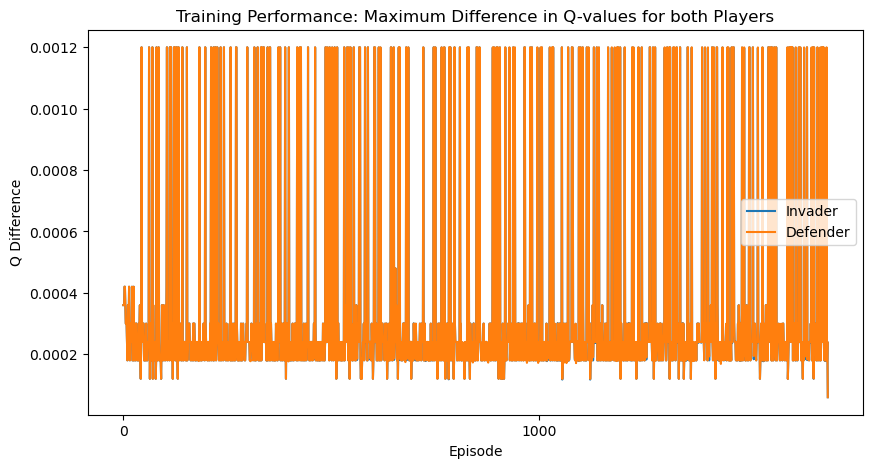

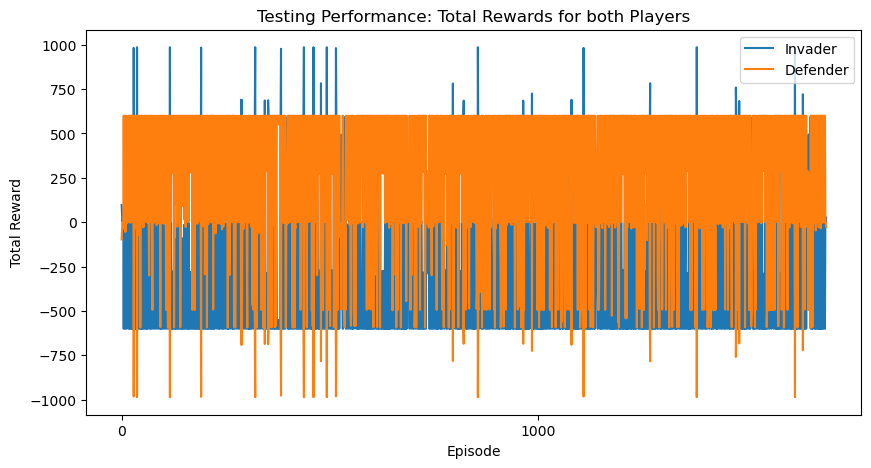

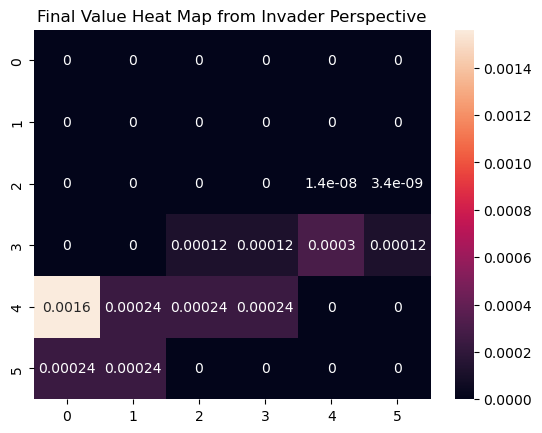

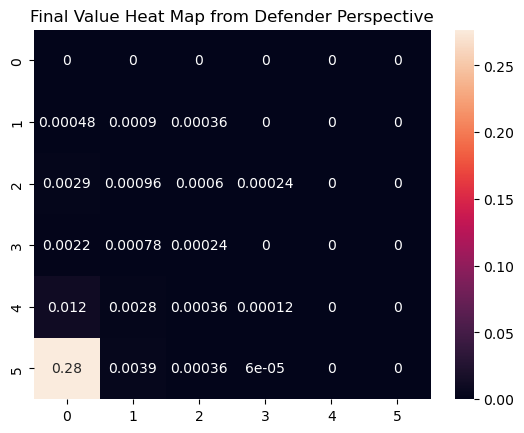

In [45]:
env = InvaderDefenderEnv()
distributed_q_learning = DistributedQLearning(env, lr=6e-5, epsilon=0.1, convergence_threshold=1e-4)
Q_inv, Q_def, policy_inv, policy_def = distributed_q_learning.train()


**2.1) Part IV**

In [46]:
_, _ = distributed_q_learning.execute_policy(testing=True)


Timestamp: 0
	Current State: ((0, 0), (5, 0))
	Invader Action: r; Defender Action: l
	Next State: ((0, 1), (5, 0))
Timestamp: 1
	Current State: ((0, 1), (5, 0))
	Invader Action: r; Defender Action: u
	Next State: ((0, 2), (4, 0))
Timestamp: 2
	Current State: ((0, 2), (4, 0))
	Invader Action: r; Defender Action: u
	Next State: ((0, 3), (3, 0))
Timestamp: 3
	Current State: ((0, 3), (3, 0))
	Invader Action: r; Defender Action: u
	Next State: ((0, 4), (2, 0))
Timestamp: 4
	Current State: ((0, 4), (2, 0))
	Invader Action: d; Defender Action: u
	Next State: ((1, 4), (1, 0))
Timestamp: 5
	Current State: ((1, 4), (1, 0))
	Invader Action: r; Defender Action: r
	Next State: ((1, 5), (1, 1))
Timestamp: 6
	Current State: ((1, 5), (1, 1))
	Invader Action: d; Defender Action: r
	Next State: ((2, 5), (1, 2))
Timestamp: 7
	Current State: ((2, 5), (1, 2))
	Invader Action: d; Defender Action: d
	Next State: ((3, 5), (2, 2))
Timestamp: 8
	Current State: ((3, 5), (2, 2))
	Invader Action: l; Defender Actio

A sample of each player's movement based on the policy dervied from the converged Q-values are shown below. Note that below is based on one testing instance of running the codeblocks.

![Distributed Q-learning Player Movement](assets/distributedqlearning_playermovement.jpeg)

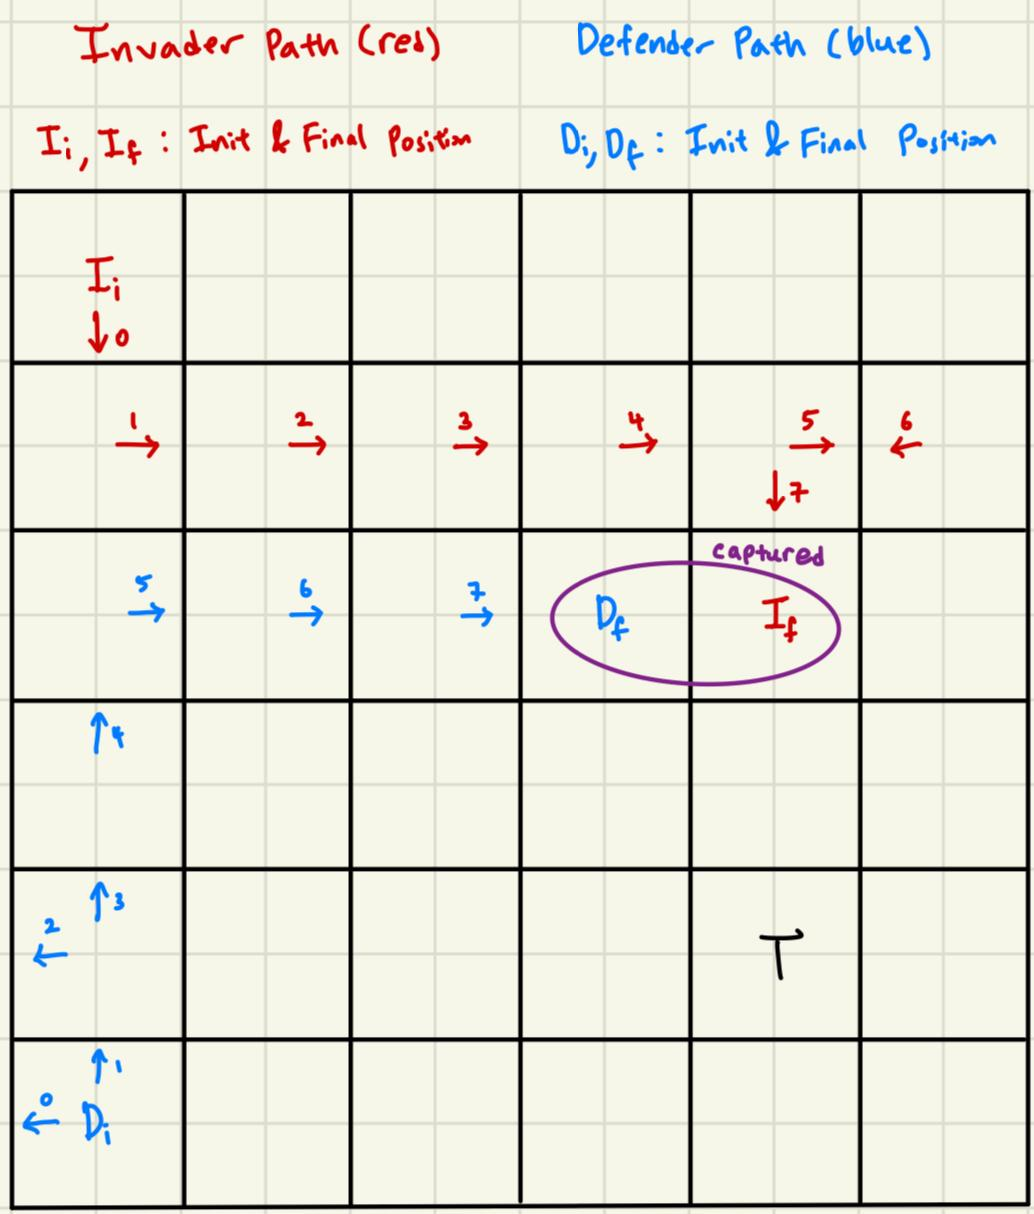

In [ ]:
from IPython.display import Image, display
display(Image(filename='fig2.1.4.jpeg', width=400))

#### 2.2 Shapley Value Iteration

In [25]:
from scipy.optimize import linprog

class ShapleyValueIteration():
    def __init__(self, env : InvaderDefenderEnv, lr=6e-5, epsilon=0.1, convergence_threshold=1e-4):
        self.env = env
        self.alpha = lr
        self.gamma = 0.95 # given 
        self.epsilon = epsilon
        self.convergence_threshold = convergence_threshold
        self.actions = env.actions
        self.U = {state:0.0 for state in env.get_all_states()} # U^(n+1)(s)
        self.U_old = {state:0.0 for state in env.get_all_states()} # U^(n)(s)
        self.policy_inv = {state: {action: 0 for action in self.env.actions} for state in self.env.get_all_states()}
        self.policy_def = {state: {action: 0 for action in self.env.actions} for state in self.env.get_all_states()}

    def build_G(self, state, role):
        # G(s) = {g_a: R(s, a) + gamma * sum_{s'} T(s, a, s') * U(s')}
        # For all joint actions a = (a1, a2)

        G = {} # {joint_action:expected_value}
        for a1 in self.actions:
            for a2 in self.actions:

                # calculate g_a
                joint_action = (a1, a2)
                transitions = self.env.get_transition_info(state, a1, a2)
                expected_value = 0.0
                for prob, next_state, _, _, done in transitions: 
                    u_next = 0 if done else self.U[next_state]
                    expected_value += prob * u_next

                # R(s, a) for invader
                if role == 'invader':
                    R_expected = sum([prob * reward_inv for prob, _, reward_inv, _, _ in transitions]) # R(s, a)
                else:
                    R_expected = sum([prob * reward_def for prob, _, _, reward_def, _ in transitions]) # R(s, a)
                G[joint_action] = R_expected + self.gamma * expected_value # g_a

        return G

    def reset_policy(self):
        self.policy_inv = {state: {action: 0 for action in self.env.actions} for state in self.env.get_all_states()}
        self.policy_def = {state: {action: 0 for action in self.env.actions} for state in self.env.get_all_states()}

    def epsilon_greedy_policy(self, G_s):
        prob = random.uniform(0, 1)
        if prob <= self.epsilon:
            return random.choice(self.env.actions), random.choice(self.env.actions)
        else:
            return max(G_s.items(), key=lambda x: x[1])[0]


    def plot_curves(self, num_episodes, u_diff_vals, inv_reward_vals, def_reward_vals):
        # Performance Curves
        if num_episodes <= 1000:
            k = 100
        else:
            k = 1000
            
        plt.figure(figsize=(10, 5))
        plt.title("Training Performance: Maximum Difference between Joint-state-value V of Iterations")
        plt.plot(range(num_episodes), u_diff_vals, label='Joint')
        plt.xticks(range(0, num_episodes, k))
        plt.xlabel("Episode")
        plt.ylabel("V Difference")
        plt.legend()
        plt.show()

        plt.figure(figsize=(10, 5))
        plt.title("Testing Performance: Total Rewards for both Players")
        plt.plot(range(num_episodes), inv_reward_vals, label='Invader')
        plt.plot(range(num_episodes), def_reward_vals, label='Defender')
        plt.xticks(range(0, num_episodes, k))
        plt.xlabel("Episode")
        plt.ylabel("Total Reward")
        plt.legend()
        plt.show()

        # Heat Maps
        fixed_defender = (0, 5)
        inv_heat_values = []
        for inv_x in range(6):
            temp = []
            for inv_y in range(6):
                inv_starting = (inv_x, inv_y)
                temp.append(self.U[(inv_starting, fixed_defender)])
            inv_heat_values.append(temp)
        inv_heat_values = np.array(inv_heat_values)

        fixed_invader = (0, 0)
        def_heat_values = []
        for def_x in range(6):
            temp = []
            for def_y in range(6):
                def_starting = (def_x, def_y)
                temp.append(self.U[(fixed_invader, def_starting)])
            def_heat_values.append(temp)
        def_heat_values = np.array(def_heat_values)

        plt.title("Final Value Heat Map from Invader Perspective")
        sns.heatmap(inv_heat_values, annot=True)
        plt.show()

        plt.title("Final Value Heat Map from Defender Perspective")
        sns.heatmap(def_heat_values, annot=True)
        plt.show()


    def execute_policy(self, testing=False):
        curr_state = self.env.reset()
        inv_total_reward, def_total_reward = 0, 0
        terminated = False
        trajectory_counter = 0
        while not terminated:
            inv_opt_actions, def_opt_actions = [], []
            for action in self.env.actions:
                if self.policy_inv[curr_state][action] > 0:
                    inv_opt_actions.append(action)
                if self.policy_def[curr_state][action] > 0:
                    def_opt_actions.append(action)
            
            inv_action = random.choice(inv_opt_actions)
            def_action = random.choice(def_opt_actions)
            new_state, (inv_reward, def_reward), terminated = self.env.step(curr_state, inv_action, def_action)
            
            inv_total_reward += inv_reward
            def_total_reward += def_reward

            if testing:
                print(f"Timestamp: {trajectory_counter}")
                print(f"\tCurrent State: {curr_state}")
                print(f"\tInvader Action: {inv_action}; Defender Action: {def_action}")
                print(f"\tNext State: {new_state}")

            trajectory_counter += 1
    
            if terminated:
                print("\tGame terminated")
                if new_state == curr_state:
                    print("\tInvader Captured")
                if new_state[0] == self.env.territory_pos:
                    print("\tTerritory Captured")
                print(f"\tTerminating State: {new_state}")
                print(f"\tNumber of Steps: {trajectory_counter}")
                return inv_total_reward, def_total_reward

            if trajectory_counter >= 200:
                print("\tExceeded 200 steps")
                return inv_total_reward, def_total_reward

            curr_state = new_state

    def solve_shapley_lp(self, inv_G_s, def_G_s):

        num_actions = len(self.actions)

        # LP for invader (primal)
        c_inv = [0] * num_actions + [-1]  # min -v
        A_inv = []
        b_inv = [0] * num_actions
        for j in range(4):
            row = []
            for i in range(4):
                row.append(-inv_G_s[(self.actions[i], self.actions[j])])
            row.append(1)
            A_inv.append(row)
        A_eq_inv = [[1] * num_actions + [0]]
        b_eq_inv = [1]
        bounds_inv = [(0, 1)] * num_actions + [(None, None)]

        res_inv = linprog(
            c_inv, A_ub=A_inv, b_ub=b_inv, A_eq=A_eq_inv, b_eq=b_eq_inv, bounds=bounds_inv, method="highs"
        )

        # LP for defender (dual)
        c_def = [0] * num_actions + [1]  # min w
        A_def = []
        b_def = [0] * num_actions
        for i in range(4):
            row = []
            for j in range(4):
                row.append(def_G_s[(self.actions[i], self.actions[j])])
            row.append(-1)
            A_def.append(row)
        A_eq_def = [[1] * num_actions + [0]]
        b_eq_def = [1]
        bounds_def = [(0, 1)] * num_actions + [(None, None)]

        res_def = linprog(c_def, A_ub=A_def, b_ub=b_def, A_eq=A_eq_def, b_eq=b_eq_def, bounds=bounds_def, method="highs"
        )

        if res_inv.success and res_def.success:
            pi_inv = res_inv.x[:4]
            pi_def = res_def.x[:4]
            v = res_inv.x[-1]  # or res_def.x[-1] — should be equal
            return v, pi_inv, pi_def
        else:
            raise RuntimeError("LP failed for invader or defender")

    def train(self):
        counter = 0
        u_diff_vals = []
        inv_reward_vals, def_reward_vals = [], []
        while True:
            state = self.env.reset()
            delta = 0
            for state in self.env.get_all_states():
                if self.env.is_terminal(state):
                    self.U[state] = 0.0
                    continue
            
                # construct G
                inv_G_s = self.build_G(state, 'invader')
                def_G_s = self.build_G(state, 'defender')
                value, pi_inv, pi_def = self.solve_shapley_lp(inv_G_s, def_G_s) # Solve LP to find best policy

                # store old U, update U
                self.U_old[state] = self.U[state]
                self.U[state] = value

                # find difference in update
                delta = max(delta, abs(self.U_old[state] - self.U[state]))

                # update policy
                for i, a in enumerate(self.actions):
                    self.policy_inv[state][a] = pi_inv[i]
                    self.policy_def[state][a] = pi_def[i]

            print(f"Episode {counter + 1}.")
            counter += 1

            # execute policy
            inv_total_reward, def_total_reward = self.execute_policy()
            print(f"\tInvader Reward: {inv_total_reward}; Defender Reward: {def_total_reward}")
                    
            # graphing
            u_diff_vals.append(delta)
            inv_reward_vals.append(inv_total_reward)
            def_reward_vals.append(def_total_reward)

            # only stop if U values converged
            if delta <= self.convergence_threshold:
                self.plot_curves(counter, u_diff_vals, inv_reward_vals, def_reward_vals)
                return self.U, self.policy_inv, self.policy_def
            

**2.2) Part I. Hyperparameter Tuning Experiments**

Hyperparameters are consistent with Distributed Q-Learning.
- learning rate = 6e-5 
- $\epsilon$ = 0.1
- convergence_threshold = 1e-4

**2.2) Part II and III**

Episode 1.
	Exceeded 200 steps
	Invader Reward: 389; Defender Reward: -389
Episode 2.
	Game terminated
	Territory Captured
	Terminating State: ((4, 4), (3, 4))
	Number of Steps: 16
	Invader Reward: 62; Defender Reward: -62
Episode 3.
	Game terminated
	Invader Captured
	Terminating State: ((2, 4), (2, 3))
	Number of Steps: 7
	Invader Reward: -5; Defender Reward: 5
Episode 4.
	Game terminated
	Territory Captured
	Terminating State: ((4, 4), (3, 4))
	Number of Steps: 8
	Invader Reward: 17; Defender Reward: -17
Episode 5.
	Game terminated
	Invader Captured
	Terminating State: ((3, 4), (3, 3))
	Number of Steps: 8
	Invader Reward: -4; Defender Reward: 4
Episode 6.
	Game terminated
	Invader Captured
	Terminating State: ((2, 4), (3, 4))
	Number of Steps: 7
	Invader Reward: -5; Defender Reward: 5
Episode 7.
	Game terminated
	Invader Captured
	Terminating State: ((2, 4), (3, 4))
	Number of Steps: 7
	Invader Reward: -5; Defender Reward: 5
Episode 8.
	Game terminated
	Invader Captured
	Terminating

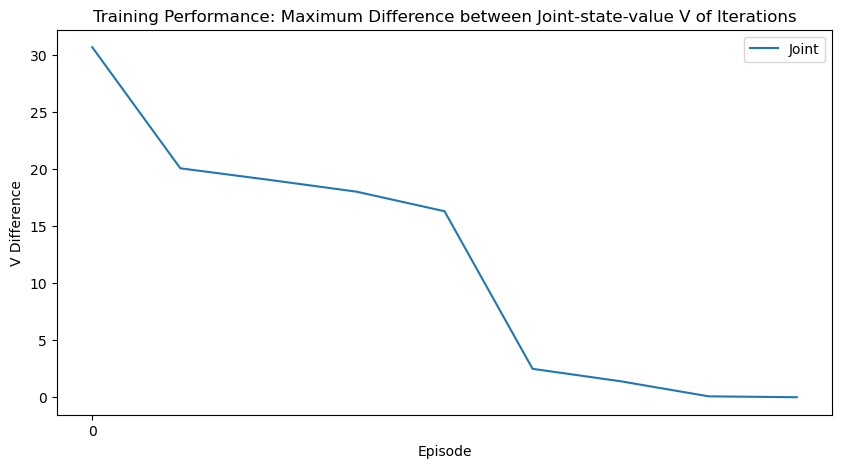

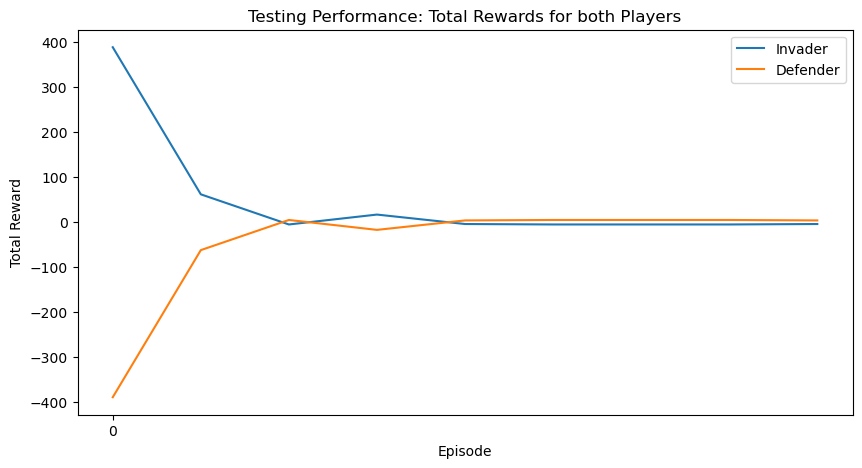

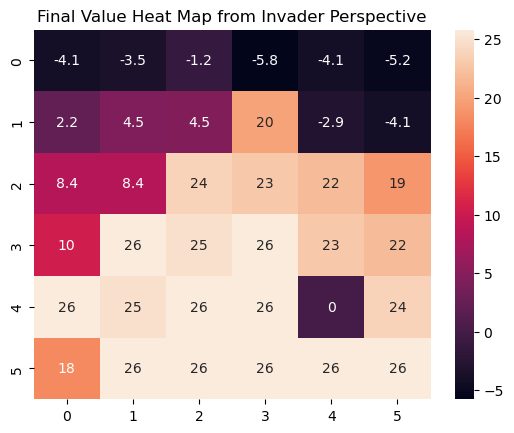

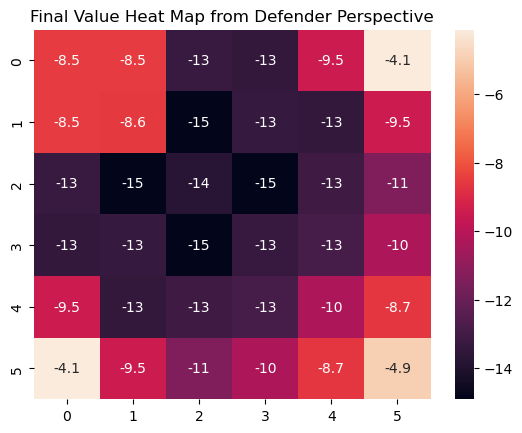

In [26]:
env = InvaderDefenderEnv()
shapley_value_iteration = ShapleyValueIteration(env, lr=6e-5, epsilon=0.1, convergence_threshold=1e-4)
U, policy_inv, policy_def = shapley_value_iteration.train()

In [27]:
_, _ = shapley_value_iteration.execute_policy(testing=True)

Timestamp: 0
	Current State: ((0, 0), (5, 0))
	Invader Action: r; Defender Action: r
	Next State: ((0, 1), (5, 1))
Timestamp: 1
	Current State: ((0, 1), (5, 1))
	Invader Action: r; Defender Action: u
	Next State: ((0, 2), (4, 1))
Timestamp: 2
	Current State: ((0, 2), (4, 1))
	Invader Action: r; Defender Action: u
	Next State: ((0, 3), (3, 1))
Timestamp: 3
	Current State: ((0, 3), (3, 1))
	Invader Action: r; Defender Action: r
	Next State: ((0, 4), (3, 2))
Timestamp: 4
	Current State: ((0, 4), (3, 2))
	Invader Action: d; Defender Action: r
	Next State: ((1, 4), (3, 3))
Timestamp: 5
	Current State: ((1, 4), (3, 3))
	Invader Action: d; Defender Action: r
	Next State: ((2, 4), (3, 4))
Timestamp: 6
	Current State: ((2, 4), (3, 4))
	Invader Action: d; Defender Action: u
	Next State: ((2, 4), (3, 4))
	Game terminated
	Invader Captured
	Terminating State: ((2, 4), (3, 4))
	Number of Steps: 7


**2.2) Part IV**

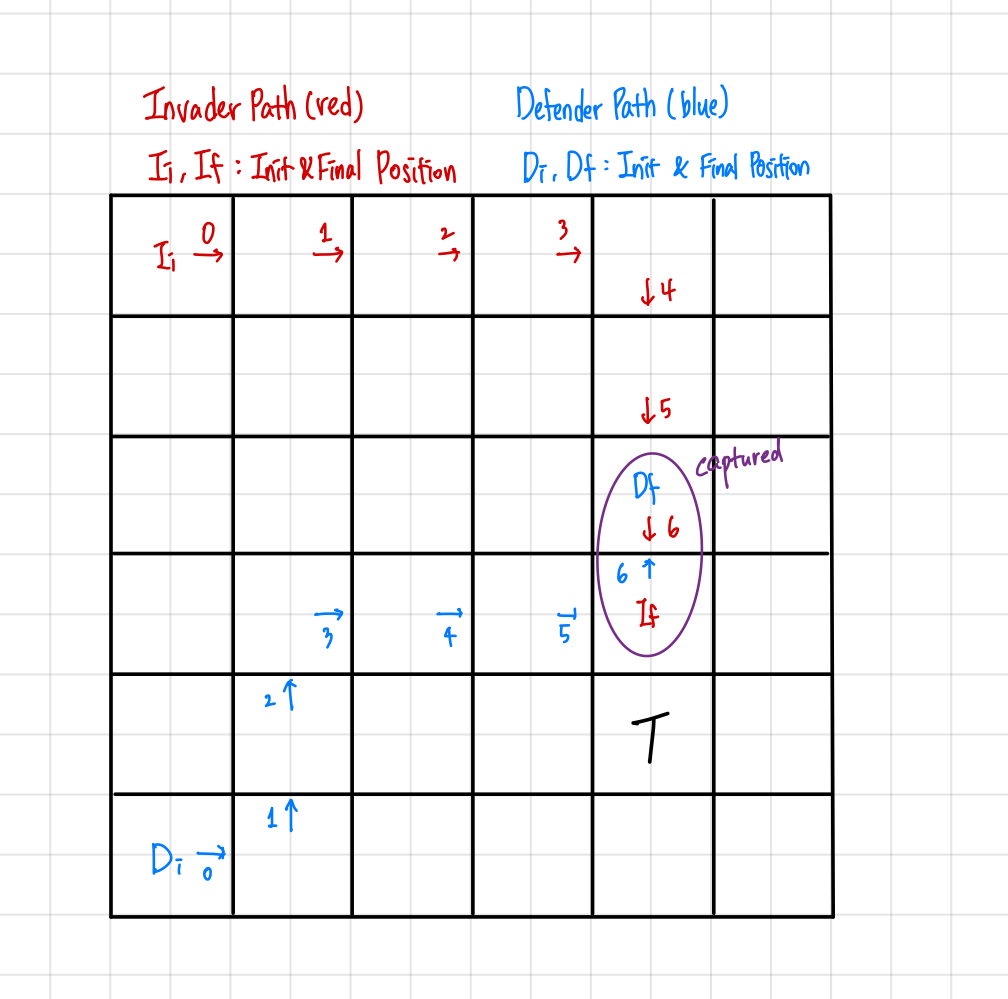

In [ ]:
from IPython.display import Image, display
display(Image(filename='fig2.2.4.jpeg', width=400))

#### 2.3 Minimax Q-learning

In [10]:
import numpy as np
import random
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.optimize import linprog


class MiniMaxQLearning:
    def __init__(self, env, lr=1e-4, epsilon=0.1):
        self.env = env
        self.alpha = lr
        self.gamma = 0.95  # discount factor given
        self.epsilon = epsilon
        self.actions = self.env.actions

        # initialize q-values for each state and joint action (invader, defender)
        # game is zero-sum so q_def = -q_inv
        self.Q_inv = {
            (state, a_inv, a_def): 0
            for state in self.env.get_all_states()
            for a_inv in self.actions
            for a_def in self.actions
        }
        self.Q_def = {
            (state, a_inv, a_def): 0
            for state in self.env.get_all_states()
            for a_inv in self.actions
            for a_def in self.actions
        }

        # set initial policy for each state as probability distribution over actions
        # for invader, use lp solution; for defender, use best response
        self.policy_inv = {
            state: {a: 0 for a in self.actions} for state in self.env.get_all_states()
        }
        self.policy_def = {
            state: {a: 0 for a in self.actions} for state in self.env.get_all_states()
        }

    def solve_minimax_lp(self, state):
        """
        solve lp for minimax equilibrium at given state.
        lp: maximize v subject to sum_a p(a)*q_inv(state, a, b) >= v for all defender actions b,
            sum_a p(a) = 1, and p(a) >= 0.
        converted to minimization (minimize -v) for linprog.
        returns: p_inv dict (action: probability), and v value.
        """
        num_actions = len(self.actions)
        # decision variables: x = [v, p(a1), p(a2), ..., p(a_k)]
        c = [-1] + [0] * num_actions  # minimize -v
        A_ub = []
        b_ub = []
        # for each defender action b: v - sum_a p(a)*q_inv(state, a, b) <= 0
        for b in self.actions:
            constraint = [1]  # coefficient for v
            for a in self.actions:
                q_val = self.Q_inv[(state, a, b)]
                constraint.append(-q_val)
            A_ub.append(constraint)
            b_ub.append(0)
        # equality: sum_a p(a) = 1
        A_eq = [[0] + [1] * num_actions]
        b_eq = [1]
        # bounds: v is unbounded; probabilities in [0,1]
        bounds = [(None, None)] + [(0, 1)] * num_actions

        res = linprog(
            c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs"
        )
        if res.success:
            solution = res.x
            v = solution[0]
            probs = solution[1:]
            prob_dict = {a: prob for a, prob in zip(self.actions, probs)}
            return prob_dict, v
        else:
            # fallback: use uniform distribution if lp fails
            uniform_prob = 1.0 / num_actions
            return {a: uniform_prob for a in self.actions}, 0

    def epsilon_greedy_policy(self, state):
        """
        return joint action (a_inv, a_def) for given state.
        with probability epsilon choose random actions;
        otherwise, invader samples from lp policy and defender chooses best response.
        """
        if random.random() < self.epsilon:
            a_inv = random.choice(self.actions)
            a_def = random.choice(self.actions)
            return a_inv, a_def
        else:
            # get lp equilibrium for invader
            p_inv, _ = self.solve_minimax_lp(state)
            a_inv = random.choices(
                self.actions, weights=[p_inv[a] for a in self.actions]
            )[0]

            # choose defender action minimizing expected invader q-value
            expected_values = {}
            for b in self.actions:
                expected_values[b] = sum(
                    p_inv[a] * self.Q_inv[(state, a, b)] for a in self.actions
                )
            min_val = min(expected_values.values())
            best_def_actions = [
                b for b, val in expected_values.items() if abs(val - min_val) < 1e-8
            ]
            a_def = random.choice(best_def_actions)
            return a_inv, a_def

    def reset_policy(self):
        """
        update policy for every state using lp solution.
        defender's policy is set as best response to invader's equilibrium.
        """
        for state in self.env.get_all_states():
            p_inv, _ = self.solve_minimax_lp(state)
            self.policy_inv[state] = p_inv

            # compute expected values for defender and choose minimal ones
            expected_values = {}
            for b in self.actions:
                expected_values[b] = sum(
                    p_inv[a] * self.Q_inv[(state, a, b)] for a in self.actions
                )
            min_val = min(expected_values.values())
            best_actions = [
                b for b, val in expected_values.items() if abs(val - min_val) < 1e-8
            ]
            num_best = len(best_actions)
            self.policy_def[state] = {
                a: (1.0 / num_best if a in best_actions else 0) for a in self.actions
            }

    def execute_policy(self, testing=False):
        """
        run one rollout (episode) using greedy (lp) policies.
        used for testing after training.
        """
        state = self.env.reset()
        inv_total_reward, def_total_reward = 0, 0
        trajectory_counter = 0
        while True:
            # choose invader actions with positive lp probability
            inv_actions = [a for a in self.actions if self.policy_inv[state][a] > 0]
            def_actions = [a for a in self.actions if self.policy_def[state][a] > 0]
            if not inv_actions:
                inv_actions = self.actions
            if not def_actions:
                def_actions = self.actions
            a_inv = random.choice(inv_actions)
            a_def = random.choice(def_actions)

            new_state, (r_inv, r_def), terminated = self.env.step(state, a_inv, a_def)
            if testing:
                print(f"step {trajectory_counter}:")
                print(f"\tstate: {state}")
                print(f"\tinvader action: {a_inv}; defender action: {a_def}")
                print(f"\tnew state: {new_state}")
            inv_total_reward += r_inv
            def_total_reward += r_def
            trajectory_counter += 1
            if terminated or trajectory_counter >= 200:
                if testing:
                    print("episode terminated")
                break
            state = new_state
        return inv_total_reward, def_total_reward

    def plot_curves(self, num_episodes, q_diff_vals, inv_reward_vals, def_reward_vals):
        # training performance: max change in q-values per episode
        plt.figure(figsize=(10, 5))
        plt.title("training performance: max q diff")
        plt.plot(range(num_episodes), q_diff_vals, label="max q diff")
        plt.xlabel("episode")
        plt.ylabel("q diff")
        plt.legend()
        plt.show()

        # testing performance: total reward per episode
        plt.figure(figsize=(10, 5))
        plt.title("testing performance: total rewards")
        plt.plot(range(num_episodes), inv_reward_vals, label="invader reward")
        plt.plot(range(num_episodes), def_reward_vals, label="defender reward")
        plt.xlabel("episode")
        plt.ylabel("total reward")
        plt.legend()
        plt.show()

        # 2d heat map for invader value (fix defender at (0,5))
        fixed_defender = (0, 5)
        inv_heat_values = []
        for i in range(self.env.grid_size):
            row = []
            for j in range(self.env.grid_size):
                state = ((i, j), fixed_defender)
                # use lp value as invader's state value
                _, v = self.solve_minimax_lp(state)
                row.append(v)
            inv_heat_values.append(row)
        inv_heat_values = np.array(inv_heat_values)
        plt.figure()
        plt.title("final value heat map (invader)")
        sns.heatmap(inv_heat_values, annot=True)
        plt.show()

        # 2d heat map for defender value (fix invader at (0,0))
        fixed_invader = (0, 0)
        def_heat_values = []
        for i in range(self.env.grid_size):
            row = []
            for j in range(self.env.grid_size):
                state = (fixed_invader, (i, j))
                # for zero-sum game, defender value is -v
                _, v = self.solve_minimax_lp(state)
                row.append(-v)
            def_heat_values.append(row)
        def_heat_values = np.array(def_heat_values)
        plt.figure()
        plt.title("final value heat map (defender)")
        sns.heatmap(def_heat_values, annot=True)
        plt.show()

    def train(self, max_episodes=50000):
        """
        train minimax q-learning over multiple episodes.
        episode length fixed at 200 steps.
        update: q(s, a_inv, a_def) += alpha * [r_inv + gamma * v(next) - q(s, a_inv, a_def)]
        defender's q is negative of invader's.
        update policies for all states after each episode.
        convergence: max change in q-values below 1e-4.
        returns learned q-values and policies.
        """
        episode = 0
        q_diff_vals = []  # max q change per episode
        inv_reward_vals = []  # total invader reward per episode (test)
        def_reward_vals = []  # total defender reward per episode (test)
        while True:
            state = self.env.reset()
            max_diff = 0
            # run one episode (up to 200 steps)
            for t in range(200):
                a_inv, a_def = self.epsilon_greedy_policy(state)
                old_q = self.Q_inv[(state, a_inv, a_def)]
                new_state, (r_inv, r_def), terminated = self.env.step(
                    state, a_inv, a_def
                )
                # get v(next) via lp solution
                _, v_next = self.solve_minimax_lp(new_state)
                # update q-value for taken joint action
                self.Q_inv[(state, a_inv, a_def)] += self.alpha * (
                    r_inv + self.gamma * v_next - self.Q_inv[(state, a_inv, a_def)]
                )
                self.Q_def[(state, a_inv, a_def)] = -self.Q_inv[(state, a_inv, a_def)]
                diff = abs(old_q - self.Q_inv[(state, a_inv, a_def)])
                max_diff = max(max_diff, diff)
                if terminated:
                    break
                state = new_state
            # update policies for all states
            self.reset_policy()
            # test rollout using greedy policies
            inv_total_reward, def_total_reward = self.execute_policy()
            print(
                f"episode {episode+1}: max q diff = {max_diff:.6f}, invader reward = {inv_total_reward}, defender reward = {def_total_reward}"
            )
            q_diff_vals.append(max_diff)
            inv_reward_vals.append(inv_total_reward)
            def_reward_vals.append(def_total_reward)
            episode += 1
            # stop if converged or after max episodes
            if max_diff < 1e-4 or episode >= max_episodes:
                self.plot_curves(episode, q_diff_vals, inv_reward_vals, def_reward_vals)
                break
        return self.Q_inv, self.Q_def, self.policy_inv, self.policy_def

In [12]:
env = InvaderDefenderEnv()
minimax_q_learning = MiniMaxQLearning(env, lr=1e-4, epsilon=0.1)
Q_inv, Q_def, policy_inv, policy_def = minimax_q_learning.train()

episode 1: max q diff = 0.000800, invader reward = -97, defender reward = 97
episode 2: max q diff = 0.000600, invader reward = -32, defender reward = 32
episode 3: max q diff = 0.000500, invader reward = -88, defender reward = 88
episode 4: max q diff = 0.000800, invader reward = -25, defender reward = 25
episode 5: max q diff = 0.000600, invader reward = -53, defender reward = 53
episode 6: max q diff = 0.000700, invader reward = -48, defender reward = 48
episode 7: max q diff = 0.000600, invader reward = -21, defender reward = 21
episode 8: max q diff = 0.000400, invader reward = -23, defender reward = 23
episode 9: max q diff = 0.000600, invader reward = -28, defender reward = 28
episode 10: max q diff = 0.000500, invader reward = -14, defender reward = 14
episode 11: max q diff = 0.000500, invader reward = 25, defender reward = -25


KeyboardInterrupt: 

**2.3) Part I. Hyperparameter Tuning Experiments**

**2.3) Part II and III**

**2.3) Part IV**

### 3. Results discussion [30 Marks]

In your report, please provide details about the results of your experiment. Include all relevant plots to support
your answers:

3.1. Did your algorithms converge? How many iterations did they take?     [5 Marks]

3.2. What were the final policies? Do the final policies agree between value iteration and Q-learning? What do
you think could explain the differences between them, if any? [5 Marks]

3.3 Looking at the final policy you obtained, were there any states in which the optimal mini-max equilibrium was
non-deterministic (that is, either defender or invader or both agents take action randomly)? Please include a
list of all such states in your report. Do you think this result is expected? Why or why not?. [5 Marks]

3.4 Based on your heat-map plots, for which initial states does the invader win and defender lose (e.g. the invader
makes it to the territory and evades capture)? Similarly, for which initial states does the defender win and
invader lose (e.g. the invader is captured before reaching the territory)? Are there any starting states in which
it is not clear whether invader and defender will win the game? Explain. [10 Marks]

3.5.Which algorithm did you feel was more reliable for solving this task? Which algorithm would be more efficient
if the state space was considerably larger?.[5 Marks]